# Attack Graphs from MITRE ATT&CK Campaigns

## Problem

The current attacker profiling maps MITRE campaign techniques → 6 MTDSim phases → **linear parameter modifiers** (speed multipliers, success bonuses). Every enhanced attacker is structurally identical — the same 6-phase kill chain with different numbers. A SolarWinds APT and a basic phishing campaign differ only in degree, not in kind.

## Goal

Model campaigns as **structurally distinct attack graphs** (DAGs) where:
- **Nodes** = techniques/actions
- **Edges** = sequencing (tactic ordering)
- Different campaigns produce **different graph shapes**, not just different parameter values

## Approach

MITRE ATT&CK does **not** provide pre-built attack graphs. The STIX bundle contains flat `campaign → uses → technique` relationships with no explicit ordering. However, techniques carry `kill_chain_phases` (14 tactics in canonical order), which provides a natural layering for DAG construction.

In [1]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict
from pathlib import Path

# Load MITRE ATT&CK STIX bundle
with open('enterprise-attack.json', 'r') as f:
    stix_bundle = json.load(f)

objects = stix_bundle['objects']
print(f"Total STIX objects: {len(objects)}")

# Build lookup structures
objects_by_id = {}
campaigns = []
attack_patterns = {}       # stix_id -> object
relationships = []
tactics_objects = {}        # x-mitre-tactic stix_id -> object

type_counts = Counter()
rel_type_counts = Counter()

for obj in objects:
    obj_type = obj.get('type', '')
    type_counts[obj_type] += 1
    
    if obj.get('revoked', False) or obj.get('x_mitre_deprecated', False):
        continue
    
    objects_by_id[obj['id']] = obj
    
    if obj_type == 'campaign':
        campaigns.append(obj)
    elif obj_type == 'attack-pattern':
        attack_patterns[obj['id']] = obj
    elif obj_type == 'relationship':
        relationships.append(obj)
        rel_type_counts[obj['relationship_type']] += 1
    elif obj_type == 'x-mitre-tactic':
        tactics_objects[obj['id']] = obj

print(f"\nObject types: {dict(type_counts)}")
print(f"\nRelationship types: {dict(rel_type_counts)}")
print(f"\nCampaigns: {len(campaigns)}")
print(f"Attack patterns (non-revoked): {len(attack_patterns)}")
print(f"Relationships: {len(relationships)}")

Total STIX objects: 24771

Object types: {'x-mitre-matrix': 1, 'course-of-action': 268, 'malware': 696, 'tool': 91, 'x-mitre-tactic': 14, 'attack-pattern': 835, 'x-mitre-analytic': 1739, 'x-mitre-data-component': 109, 'x-mitre-data-source': 38, 'intrusion-set': 187, 'campaign': 52, 'x-mitre-detection-strategy': 691, 'relationship': 20048, 'identity': 1, 'marking-definition': 1}

Relationship types: {'uses': 17270, 'mitigates': 1445, 'subtechnique-of': 477, 'detects': 691, 'revoked-by': 140, 'attributed-to': 25}

Campaigns: 52
Attack patterns (non-revoked): 691
Relationships: 20048


In [2]:
# Extract canonical tactic ordering from the x-mitre-matrix object
matrix_obj = next(obj for obj in objects if obj.get('type') == 'x-mitre-matrix')
tactic_refs = matrix_obj['tactic_refs']

# Resolve tactic refs to short names
TACTIC_ORDER = []
for ref in tactic_refs:
    tactic_obj = objects_by_id.get(ref)
    if tactic_obj:
        short_name = tactic_obj['x_mitre_shortname']
        TACTIC_ORDER.append(short_name)

TACTIC_INDEX = {t: i for i, t in enumerate(TACTIC_ORDER)}

print("Canonical ATT&CK Tactic Ordering (14 tactics):")
print("=" * 50)
for i, t in enumerate(TACTIC_ORDER):
    print(f"  {i:2d}. {t}")

Canonical ATT&CK Tactic Ordering (14 tactics):
   0. reconnaissance
   1. resource-development
   2. initial-access
   3. execution
   4. persistence
   5. privilege-escalation
   6. defense-evasion
   7. credential-access
   8. discovery
   9. lateral-movement
  10. collection
  11. command-and-control
  12. exfiltration
  13. impact


## Part 1: The Current Kill Chain Model

The current attacker model in MTDSim uses a **fixed 6-phase sequential kill chain** (from `attack_operation.py`). Every attacker — regardless of MITRE campaign — follows the same graph structure. Enhanced profiles only modify the **numbers on the nodes** (durations, success rates), never the structure.

| Phase | Base Duration | Maps to ATT&CK Tactics |
|-------|--------------|------------------------|
| SCAN_HOST | 5s | Reconnaissance, Discovery |
| ENUM_HOST | 5s | Resource Development, Collection |
| SCAN_PORT | 25s | Initial Access, Execution |
| EXPLOIT_VULN | 15s | Privilege Escalation, Defense Evasion, Persistence |
| BRUTE_FORCE | 20s | Credential Access |
| SCAN_NEIGHBOR | 5s | Lateral Movement, C2, Exfiltration, Impact |

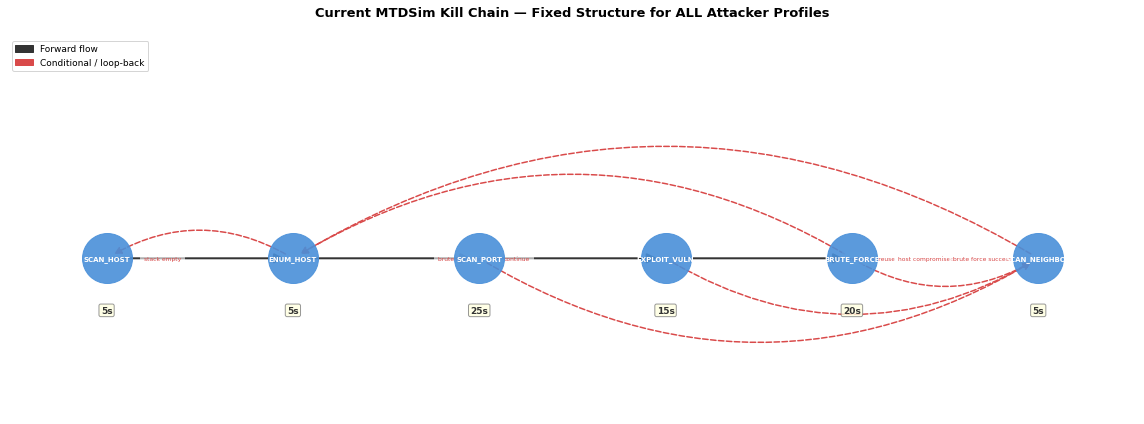


⚠ Key observation: This graph is IDENTICAL for every attacker profile.
  Enhanced profiles only change the numbers (durations, success rates),
  never the graph structure itself.


In [3]:
# Current MTDSim kill chain as a directed graph
# Shows the fixed structure from attack_operation.py

ATTACK_DURATION = {
    'SCAN_HOST': 5, 'ENUM_HOST': 5, 'SCAN_PORT': 25,
    'EXPLOIT_VULN': 15, 'BRUTE_FORCE': 20, 'SCAN_NEIGHBOR': 5,
}

G_chain = nx.DiGraph()

phases = ['SCAN_HOST', 'ENUM_HOST', 'SCAN_PORT', 'EXPLOIT_VULN', 'BRUTE_FORCE', 'SCAN_NEIGHBOR']
for p in phases:
    G_chain.add_node(p, duration=ATTACK_DURATION[p])

# Forward edges (primary kill chain flow)
forward = [
    ('SCAN_HOST', 'ENUM_HOST'),
    ('ENUM_HOST', 'SCAN_PORT'),
    ('SCAN_PORT', 'EXPLOIT_VULN'),
    ('EXPLOIT_VULN', 'BRUTE_FORCE'),
]

# Conditional / loop-back edges (from attack_operation.py)
conditional = [
    ('SCAN_PORT', 'SCAN_NEIGHBOR', 'credential reuse'),      # line 256: user_reuse → skip to scan_neighbors
    ('EXPLOIT_VULN', 'SCAN_NEIGHBOR', 'host compromised'),   # line 305: compromised → scan neighbors
    ('BRUTE_FORCE', 'SCAN_NEIGHBOR', 'brute force success'), # line 322: success → scan neighbors
    ('BRUTE_FORCE', 'ENUM_HOST', 'brute force fail'),        # line 324: fail → try next host
    ('SCAN_NEIGHBOR', 'ENUM_HOST', 'continue'),              # line 339: found neighbors → enum next
    ('ENUM_HOST', 'SCAN_HOST', 'stack empty'),               # line 93: no hosts → rescan
]

for u, v in forward:
    G_chain.add_edge(u, v, edge_type='forward')
for u, v, label in conditional:
    G_chain.add_edge(u, v, edge_type='conditional', label=label)

# Layout
pos = {
    'SCAN_HOST':    (0, 0),
    'ENUM_HOST':    (1.5, 0),
    'SCAN_PORT':    (3, 0),
    'EXPLOIT_VULN': (4.5, 0),
    'BRUTE_FORCE':  (6, 0),
    'SCAN_NEIGHBOR':(7.5, 0),
}

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Draw forward edges
forward_edges = [(u, v) for u, v, d in G_chain.edges(data=True) if d['edge_type'] == 'forward']
cond_edges = [(u, v) for u, v, d in G_chain.edges(data=True) if d['edge_type'] == 'conditional']

nx.draw_networkx_nodes(G_chain, pos, ax=ax, node_color='#4A90D9', node_size=2500, alpha=0.9)
nx.draw_networkx_labels(G_chain, pos, ax=ax, font_size=7, font_weight='bold', font_color='white')

# Forward edges: solid arrows
nx.draw_networkx_edges(G_chain, pos, edgelist=forward_edges, ax=ax,
                       edge_color='#333', width=2, arrows=True, arrowsize=20,
                       connectionstyle='arc3,rad=0.0')

# Conditional edges: curved dashed arrows
nx.draw_networkx_edges(G_chain, pos, edgelist=cond_edges, ax=ax,
                       edge_color='#D94A4A', width=1.5, style='dashed', arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.3')

# Add duration annotations
for node, (x, y) in pos.items():
    dur = ATTACK_DURATION[node]
    ax.text(x, y - 0.15, f'{dur}s', ha='center', va='top', fontsize=9,
            fontweight='bold', color='#333',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# Edge labels for conditional
edge_labels = {(u, v): d.get('label', '') for u, v, d in G_chain.edges(data=True) if d['edge_type'] == 'conditional'}
nx.draw_networkx_edge_labels(G_chain, pos, edge_labels, ax=ax, font_size=6, font_color='#D94A4A',
                             label_pos=0.3, bbox=dict(alpha=0.6, facecolor='white', edgecolor='none'))

# Legend
legend_elements = [
    mpatches.Patch(color='#333', label='Forward flow'),
    mpatches.Patch(color='#D94A4A', label='Conditional / loop-back'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.set_title("Current MTDSim Kill Chain — Fixed Structure for ALL Attacker Profiles",
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(-0.8, 8.3)
ax.set_ylim(-0.5, 0.7)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n⚠ Key observation: This graph is IDENTICAL for every attacker profile.")
print("  Enhanced profiles only change the numbers (durations, success rates),")
print("  never the graph structure itself.")

## Part 2: Framework for Attack Graph Construction

### Approach: Tactic-Ordering-Based DAG

Since MITRE ATT&CK has no explicit attack graphs, we construct them using the **canonical tactic ordering** as layers:

1. **Layers** = 14 ATT&CK tactics in matrix order (only populated tactics get nodes)
2. **Nodes** = techniques the campaign uses, placed at their **earliest** tactic
3. **Edges** = techniques in adjacent populated layers are fully connected (bipartite)
4. **Sub-techniques** get refinement edges from their parent technique
5. Virtual **START** and **END** nodes frame the graph

This produces structurally different DAGs per campaign because:
- Campaigns use **different subsets** of tactics → different layer configurations
- Campaigns have **different technique distributions** across layers → different widths
- A defense-evasion-heavy campaign looks fundamentally different from a lateral-movement-heavy one

In [4]:
# --- Data extraction helpers ---

# Build relationship index: source_ref -> list of relationships
rels_by_source = defaultdict(list)
rels_by_type = defaultdict(list)
for rel in relationships:
    rels_by_source[rel['source_ref']].append(rel)
    rels_by_type[rel['relationship_type']].append(rel)

# Sub-technique map: child_stix_id -> parent_stix_id
subtechnique_parents = {}
for rel in rels_by_type.get('subtechnique-of', []):
    subtechnique_parents[rel['source_ref']] = rel['target_ref']

def get_ext_id(obj):
    """Extract external ID (e.g., T1059, C0024) from a STIX object."""
    for ref in obj.get('external_references', []):
        if ref.get('source_name') == 'mitre-attack' and 'external_id' in ref:
            return ref['external_id']
    return None

def get_campaign_by_ext_id(ext_id):
    """Find a campaign STIX object by its external ID (e.g., 'C0024')."""
    for c in campaigns:
        if get_ext_id(c) == ext_id:
            return c
    return None

def get_campaign_techniques(campaign_stix_id):
    """
    Extract all techniques used by a campaign.
    Returns list of dicts: {stix_id, ext_id, name, tactics, is_subtechnique, parent_ext_id}
    """
    techniques = []
    seen = set()
    
    for rel in rels_by_source.get(campaign_stix_id, []):
        if rel['relationship_type'] != 'uses':
            continue
        target = objects_by_id.get(rel['target_ref'])
        if not target or target['type'] != 'attack-pattern':
            continue
        if target['id'] in seen:
            continue
        seen.add(target['id'])
        
        # Extract tactics from kill_chain_phases
        tactics = []
        for phase in target.get('kill_chain_phases', []):
            if phase.get('kill_chain_name') == 'mitre-attack':
                tactics.append(phase['phase_name'])
        
        ext_id = get_ext_id(target)
        is_sub = target.get('x_mitre_is_subtechnique', False)
        parent_id = subtechnique_parents.get(target['id'])
        parent_ext = get_ext_id(objects_by_id[parent_id]) if parent_id and parent_id in objects_by_id else None
        
        techniques.append({
            'stix_id': target['id'],
            'ext_id': ext_id,
            'name': target['name'],
            'tactics': tactics,
            'is_subtechnique': is_sub,
            'parent_ext_id': parent_ext,
        })
    
    return techniques

# Test: extract SolarWinds (C0024) techniques
c0024 = get_campaign_by_ext_id('C0024')
c0024_techs = get_campaign_techniques(c0024['id'])
print(f"SolarWinds Compromise (C0024): {len(c0024_techs)} techniques")
print(f"  Sub-techniques: {sum(1 for t in c0024_techs if t['is_subtechnique'])}")
print(f"  Tactics covered: {sorted(set(t for tech in c0024_techs for t in tech['tactics']))}")

SolarWinds Compromise (C0024): 71 techniques
  Sub-techniques: 49
  Tactics covered: ['collection', 'command-and-control', 'credential-access', 'defense-evasion', 'discovery', 'execution', 'exfiltration', 'initial-access', 'lateral-movement', 'persistence', 'privilege-escalation', 'reconnaissance', 'resource-development']


In [5]:
# --- Attack graph construction ---

def build_campaign_attack_graph(techniques, tactic_order=TACTIC_ORDER, tactic_index=TACTIC_INDEX):
    """
    Build a DAG from a campaign's techniques using tactic ordering as layers.
    
    Returns: (nx.DiGraph, dict of positions for layout)
    """
    G = nx.DiGraph()
    
    # Group techniques by their earliest tactic layer
    layers = defaultdict(list)  # tactic_index -> list of technique dicts
    for tech in techniques:
        if not tech['tactics']:
            continue
        # Place at earliest tactic
        earliest_idx = min(tactic_index.get(t, 999) for t in tech['tactics'])
        if earliest_idx == 999:
            continue
        layers[earliest_idx].append(tech)
    
    if not layers:
        return G, {}
    
    # Sort layer indices
    populated_layers = sorted(layers.keys())
    
    # Add START and END nodes
    G.add_node('START', node_type='virtual', label='START')
    G.add_node('END', node_type='virtual', label='END')
    
    # Add technique nodes per layer
    for layer_idx in populated_layers:
        tactic_name = tactic_order[layer_idx]
        for tech in layers[layer_idx]:
            G.add_node(tech['ext_id'],
                       name=tech['name'],
                       tactics=tech['tactics'],
                       tactic_layer=layer_idx,
                       tactic_name=tactic_name,
                       is_subtechnique=tech['is_subtechnique'],
                       parent_ext_id=tech.get('parent_ext_id'),
                       node_type='technique')
    
    # Connect adjacent populated layers (bipartite edges)
    for i in range(len(populated_layers)):
        curr_layer = populated_layers[i]
        curr_techs = [t['ext_id'] for t in layers[curr_layer]]
        
        if i == 0:
            # START -> first layer
            for t in curr_techs:
                G.add_edge('START', t, edge_type='flow')
        
        if i < len(populated_layers) - 1:
            next_layer = populated_layers[i + 1]
            next_techs = [t['ext_id'] for t in layers[next_layer]]
            for t1 in curr_techs:
                for t2 in next_techs:
                    G.add_edge(t1, t2, edge_type='flow')
        
        if i == len(populated_layers) - 1:
            # Last layer -> END
            for t in curr_techs:
                G.add_edge(t, 'END', edge_type='flow')
    
    # Add sub-technique refinement edges
    tech_ids_in_graph = set(G.nodes())
    for tech in techniques:
        if tech['is_subtechnique'] and tech['parent_ext_id']:
            if tech['ext_id'] in tech_ids_in_graph and tech['parent_ext_id'] in tech_ids_in_graph:
                G.add_edge(tech['parent_ext_id'], tech['ext_id'], edge_type='subtechnique')
    
    # Compute positions for layered layout
    positions = {}
    # Virtual nodes
    positions['START'] = (-1, 0)
    positions['END'] = (len(populated_layers), 0)
    
    for li, layer_idx in enumerate(populated_layers):
        techs_in_layer = [t['ext_id'] for t in layers[layer_idx]]
        n = len(techs_in_layer)
        for j, tid in enumerate(techs_in_layer):
            y = (j - (n - 1) / 2) * 0.8  # spread vertically, centered at 0
            positions[tid] = (li, y)
    
    return G, positions


def compute_graph_metrics(G):
    """Compute structural metrics for an attack graph."""
    tech_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'technique']
    flow_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'flow']
    sub_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'subtechnique']
    
    # Width profile: techniques per tactic layer
    layer_counts = Counter()
    for n in tech_nodes:
        layer_counts[G.nodes[n]['tactic_layer']] += 1
    
    populated_layers = sorted(layer_counts.keys())
    width_profile = [(TACTIC_ORDER[l], layer_counts[l]) for l in populated_layers]
    
    # Longest path (using topological sort on flow edges only)
    flow_G = nx.DiGraph()
    flow_G.add_edges_from(flow_edges)
    try:
        longest = nx.dag_longest_path_length(flow_G)
    except nx.NetworkXError:
        longest = 0
    
    return {
        'num_techniques': len(tech_nodes),
        'num_flow_edges': len(flow_edges),
        'num_sub_edges': len(sub_edges),
        'tactic_coverage': len(populated_layers),
        'max_width': max(layer_counts.values()) if layer_counts else 0,
        'width_profile': width_profile,
        'longest_path': longest,
        'density': nx.density(G),
    }


# Quick test
G_test, pos_test = build_campaign_attack_graph(c0024_techs)
metrics_test = compute_graph_metrics(G_test)
print(f"SolarWinds graph: {metrics_test['num_techniques']} techniques, "
      f"{metrics_test['num_flow_edges']} flow edges, "
      f"{metrics_test['tactic_coverage']}/14 tactics covered")
print(f"Max layer width: {metrics_test['max_width']}")
print(f"Width profile:")
for tactic, count in metrics_test['width_profile']:
    bar = '█' * count
    print(f"  {tactic:25s} {bar} ({count})")

SolarWinds graph: 71 techniques, 397 flow edges, 13/14 tactics covered
Max layer width: 15
Width profile:
  reconnaissance            █ (1)
  resource-development      ███ (3)
  initial-access            ████████ (8)
  execution                 █████ (5)
  persistence               █████ (5)
  privilege-escalation      █ (1)
  defense-evasion           ███████████████ (15)
  credential-access         ████████ (8)
  discovery                 ██████████ (10)
  lateral-movement          ███ (3)
  collection                ██████ (6)
  command-and-control       █████ (5)
  exfiltration              █ (1)


In [6]:
# --- Visualization helper ---

# Color map: one color per tactic
TACTIC_COLORS = plt.cm.tab20(np.linspace(0, 1, 14))

def draw_attack_graph(G, positions, title, figsize=None):
    """Draw a campaign attack graph with layered layout."""
    tech_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'technique']
    virtual_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'virtual']
    
    if not tech_nodes:
        print("No technique nodes to draw.")
        return
    
    # Auto-size figure
    max_width = max(
        sum(1 for n in tech_nodes if G.nodes[n]['tactic_layer'] == layer)
        for layer in set(G.nodes[n]['tactic_layer'] for n in tech_nodes)
    )
    n_layers = len(set(G.nodes[n]['tactic_layer'] for n in tech_nodes))
    if figsize is None:
        figsize = (max(14, n_layers * 2.2), max(6, max_width * 0.9))
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Node colors by tactic layer
    node_colors = []
    node_sizes = []
    for n in tech_nodes:
        layer = G.nodes[n]['tactic_layer']
        node_colors.append(TACTIC_COLORS[layer])
        node_sizes.append(200 if G.nodes[n].get('is_subtechnique') else 350)
    
    # Draw flow edges
    flow_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'flow'
                  and u not in virtual_nodes and v not in virtual_nodes]
    sub_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'subtechnique']
    start_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'flow' and u == 'START']
    end_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'flow' and v == 'END']
    
    # Flow edges (light gray, thin)
    nx.draw_networkx_edges(G, positions, edgelist=flow_edges, ax=ax,
                           edge_color='#ccc', width=0.5, arrows=True, arrowsize=8, alpha=0.6)
    
    # START/END edges
    nx.draw_networkx_edges(G, positions, edgelist=start_edges + end_edges, ax=ax,
                           edge_color='#999', width=1, arrows=True, arrowsize=10, alpha=0.5)
    
    # Sub-technique edges (dashed, colored)
    if sub_edges:
        nx.draw_networkx_edges(G, positions, edgelist=sub_edges, ax=ax,
                               edge_color='#E67E22', width=1.5, style='dashed',
                               arrows=True, arrowsize=10, alpha=0.8)
    
    # Draw technique nodes
    nx.draw_networkx_nodes(G, positions, nodelist=tech_nodes, ax=ax,
                           node_color=node_colors, node_size=node_sizes,
                           edgecolors='#333', linewidths=0.5, alpha=0.9)
    
    # Draw virtual nodes
    nx.draw_networkx_nodes(G, positions, nodelist=virtual_nodes, ax=ax,
                           node_color='#333', node_size=400, node_shape='D', alpha=0.8)
    
    # Labels
    tech_labels = {n: n for n in tech_nodes}
    virtual_labels = {n: n for n in virtual_nodes}
    nx.draw_networkx_labels(G, positions, labels=tech_labels, ax=ax,
                           font_size=5, font_weight='bold')
    nx.draw_networkx_labels(G, positions, labels=virtual_labels, ax=ax,
                           font_size=8, font_weight='bold', font_color='white')
    
    # Add tactic column headers
    layer_x_positions = {}
    for n in tech_nodes:
        layer = G.nodes[n]['tactic_layer']
        x = positions[n][0]
        layer_x_positions[layer] = x
    
    y_top = max(positions[n][1] for n in G.nodes()) + 1.2
    for layer, x in layer_x_positions.items():
        tactic_label = TACTIC_ORDER[layer].replace('-', '\n')
        ax.text(x, y_top, tactic_label, ha='center', va='bottom', fontsize=7,
                fontweight='bold', color=TACTIC_COLORS[layer],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor=TACTIC_COLORS[layer], alpha=0.8))
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=30)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def print_metrics(metrics, campaign_name):
    """Print formatted metrics for an attack graph."""
    print(f"\n{'=' * 60}")
    print(f"  {campaign_name} — Attack Graph Metrics")
    print(f"{'=' * 60}")
    print(f"  Techniques:      {metrics['num_techniques']}")
    print(f"  Flow edges:      {metrics['num_flow_edges']}")
    print(f"  Sub-tech edges:  {metrics['num_sub_edges']}")
    print(f"  Tactic coverage: {metrics['tactic_coverage']}/14")
    print(f"  Max layer width: {metrics['max_width']}")
    print(f"  Longest path:    {metrics['longest_path']}")
    print(f"  Graph density:   {metrics['density']:.4f}")
    print(f"\n  Width profile:")
    for tactic, count in metrics['width_profile']:
        bar = '█' * count
        print(f"    {tactic:25s} {bar} ({count})")

print("Visualization helpers defined.")

Visualization helpers defined.


## Part 3: Example Campaign Attack Graphs

Three structurally diverse campaigns to compare:

1. **SolarWinds Compromise (C0024)** — 71 techniques, sophisticated supply-chain APT with broad tactic coverage
2. **Night Dragon (C0002)** — Classic cyber espionage campaign, moderate breadth
3. **3CX Supply Chain Compromise (C0057)** — Supply chain attack, different shape

Under the current model, these differ only in scalar parameters. As attack graphs, their **shapes** should be visibly distinct.

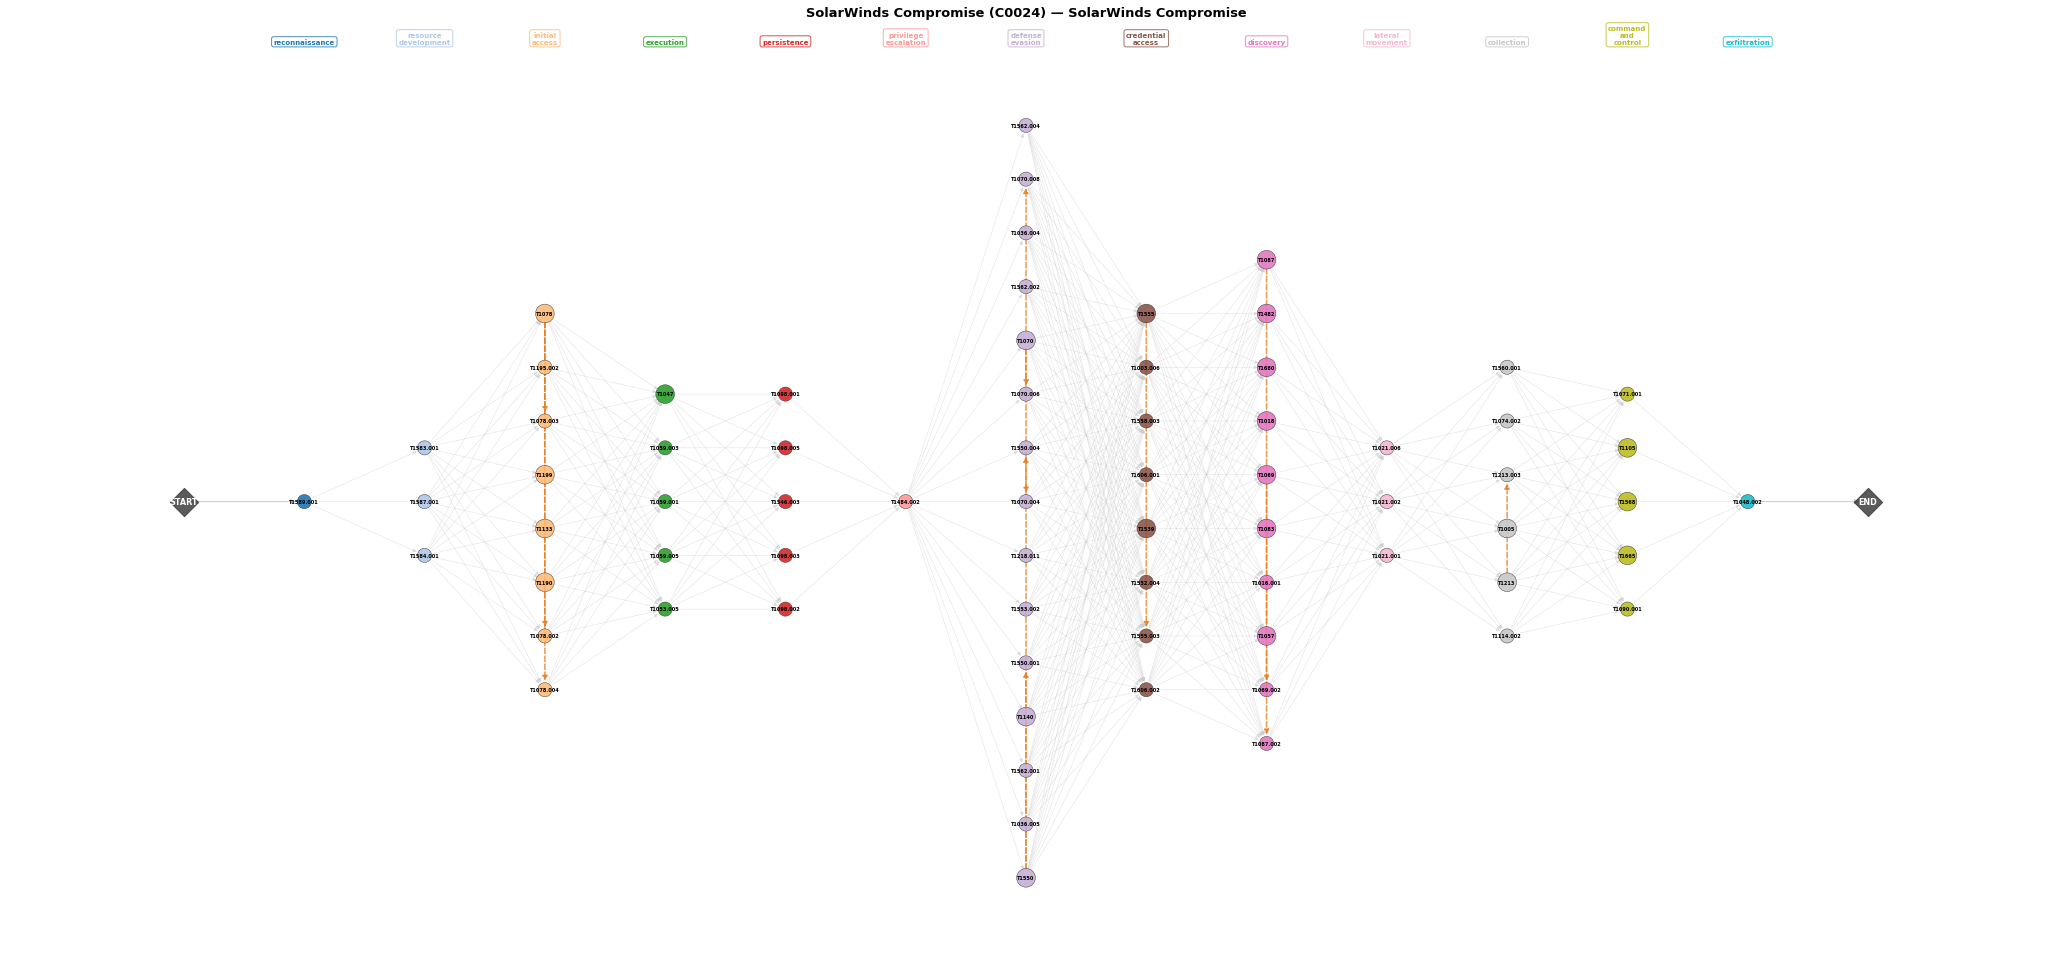


  SolarWinds Compromise — Attack Graph Metrics
  Techniques:      71
  Flow edges:      397
  Sub-tech edges:  12
  Tactic coverage: 13/14
  Max layer width: 15
  Longest path:    14
  Graph density:   0.0778

  Width profile:
    reconnaissance            █ (1)
    resource-development      ███ (3)
    initial-access            ████████ (8)
    execution                 █████ (5)
    persistence               █████ (5)
    privilege-escalation      █ (1)
    defense-evasion           ███████████████ (15)
    credential-access         ████████ (8)
    discovery                 ██████████ (10)
    lateral-movement          ███ (3)
    collection                ██████ (6)
    command-and-control       █████ (5)
    exfiltration              █ (1)


In [7]:
# --- Campaign 1: SolarWinds Compromise (C0024) ---

c0024 = get_campaign_by_ext_id('C0024')
c0024_techs = get_campaign_techniques(c0024['id'])
G_solar, pos_solar = build_campaign_attack_graph(c0024_techs)
m_solar = compute_graph_metrics(G_solar)

draw_attack_graph(G_solar, pos_solar, 
                  f"SolarWinds Compromise (C0024) — {c0024['name']}")
print_metrics(m_solar, "SolarWinds Compromise")

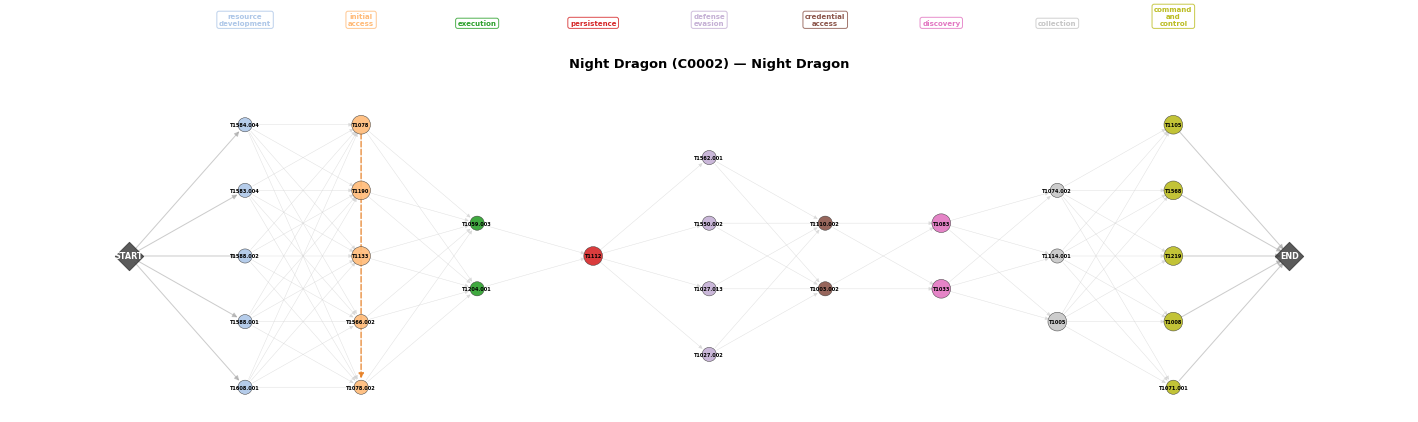


  Night Dragon — Attack Graph Metrics
  Techniques:      29
  Flow edges:      84
  Sub-tech edges:  1
  Tactic coverage: 9/14
  Max layer width: 5
  Longest path:    10
  Graph density:   0.0914

  Width profile:
    resource-development      █████ (5)
    initial-access            █████ (5)
    execution                 ██ (2)
    persistence               █ (1)
    defense-evasion           ████ (4)
    credential-access         ██ (2)
    discovery                 ██ (2)
    collection                ███ (3)
    command-and-control       █████ (5)


In [8]:
# --- Campaign 2: Night Dragon (C0002) ---

c0002 = get_campaign_by_ext_id('C0002')
c0002_techs = get_campaign_techniques(c0002['id'])
G_night, pos_night = build_campaign_attack_graph(c0002_techs)
m_night = compute_graph_metrics(G_night)

draw_attack_graph(G_night, pos_night,
                  f"Night Dragon (C0002) — {c0002['name']}")
print_metrics(m_night, "Night Dragon")

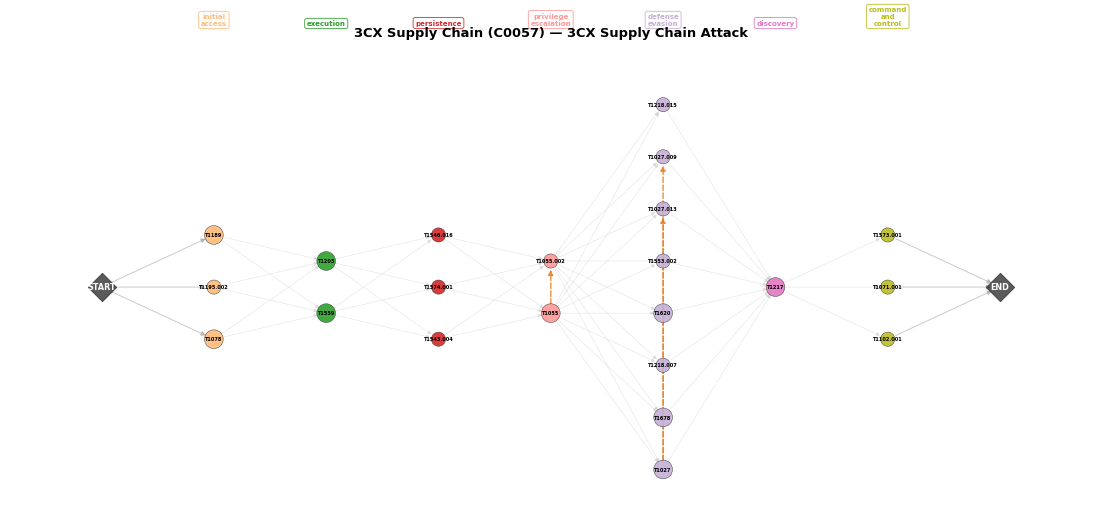


  3CX Supply Chain — Attack Graph Metrics
  Techniques:      22
  Flow edges:      51
  Sub-tech edges:  3
  Tactic coverage: 7/14
  Max layer width: 8
  Longest path:    8
  Graph density:   0.0978

  Width profile:
    initial-access            ███ (3)
    execution                 ██ (2)
    persistence               ███ (3)
    privilege-escalation      ██ (2)
    defense-evasion           ████████ (8)
    discovery                 █ (1)
    command-and-control       ███ (3)


In [9]:
# --- Campaign 3: 3CX Supply Chain Compromise (C0057) ---

c0057 = get_campaign_by_ext_id('C0057')
c0057_techs = get_campaign_techniques(c0057['id'])
G_3cx, pos_3cx = build_campaign_attack_graph(c0057_techs)
m_3cx = compute_graph_metrics(G_3cx)

draw_attack_graph(G_3cx, pos_3cx,
                  f"3CX Supply Chain (C0057) — {c0057['name']}")
print_metrics(m_3cx, "3CX Supply Chain")

Comparative Metrics
Metric                   SolarWinds (C0024)Night Dragon (C0002)3CX Supply Chain (C0057)
--------------------------------------------------------------------------------
  Techniques                             71                29                22
  Flow edges                            397                84                51
  Sub-tech edges                         12                 1                 3
  Tactic coverage                        13                 9                 7
  Max layer width                        15                 5                 8
  Longest path                           14                10                 8


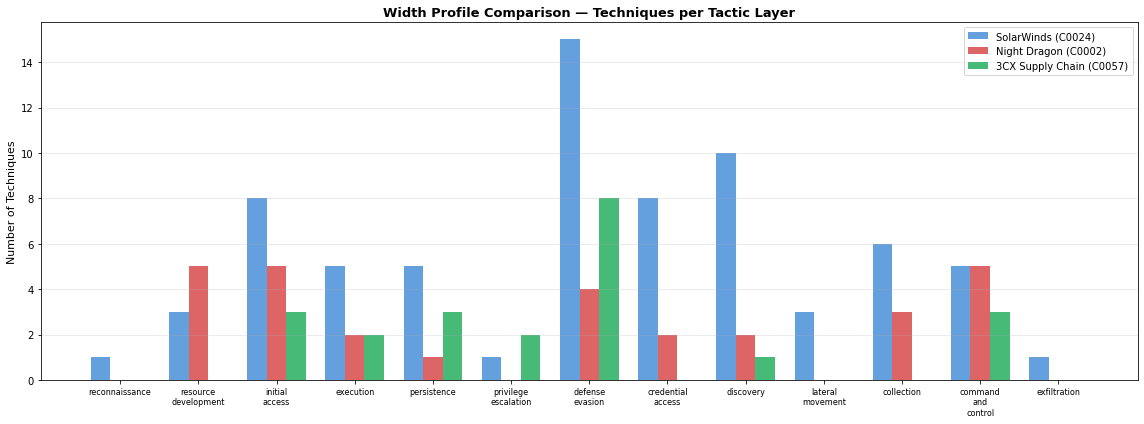


Key observation: These three campaigns have fundamentally different SHAPES.
SolarWinds is broad and deep. Night Dragon is narrower. 3CX is focused differently.
Under the current model, these differences collapse to scalar parameter variations.


In [10]:
# --- Comparative Analysis ---

campaign_data = [
    ('SolarWinds (C0024)', m_solar),
    ('Night Dragon (C0002)', m_night),
    ('3CX Supply Chain (C0057)', m_3cx),
]

# 1. Metrics comparison table
print("Comparative Metrics")
print("=" * 80)
header = f"{'Metric':<25s}"
for name, _ in campaign_data:
    header += f"{name:>18s}"
print(header)
print("-" * 80)

for metric_key, metric_label in [
    ('num_techniques', 'Techniques'),
    ('num_flow_edges', 'Flow edges'),
    ('num_sub_edges', 'Sub-tech edges'),
    ('tactic_coverage', 'Tactic coverage'),
    ('max_width', 'Max layer width'),
    ('longest_path', 'Longest path'),
]:
    row = f"  {metric_label:<23s}"
    for _, m in campaign_data:
        row += f"{m[metric_key]:>18}"
    print(row)

# 2. Width profile comparison (grouped bar chart)
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Get all tactics that appear in any campaign
all_tactics_used = set()
for _, m in campaign_data:
    for tactic, _ in m['width_profile']:
        all_tactics_used.add(tactic)

# Order by canonical tactic order
tactics_to_plot = [t for t in TACTIC_ORDER if t in all_tactics_used]
x = np.arange(len(tactics_to_plot))
bar_width = 0.25

colors = ['#4A90D9', '#D94A4A', '#27AE60']

for i, (name, m) in enumerate(campaign_data):
    width_dict = dict(m['width_profile'])
    heights = [width_dict.get(t, 0) for t in tactics_to_plot]
    ax.bar(x + i * bar_width, heights, bar_width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + bar_width)
ax.set_xticklabels([t.replace('-', '\n') for t in tactics_to_plot], fontsize=8, rotation=0)
ax.set_ylabel('Number of Techniques', fontsize=11)
ax.set_title('Width Profile Comparison — Techniques per Tactic Layer', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observation: These three campaigns have fundamentally different SHAPES.")
print("SolarWinds is broad and deep. Night Dragon is narrower. 3CX is focused differently.")
print("Under the current model, these differences collapse to scalar parameter variations.")

## Part 4: Batch Analysis — All Campaigns

Build attack graphs for all campaigns with >= 3 techniques to understand the structural diversity across the full MITRE ATT&CK campaign dataset.

In [11]:
# Build attack graphs for all campaigns (>= 3 techniques)

MIN_TECHNIQUES = 3
all_campaign_metrics = []

for campaign in campaigns:
    ext_id = get_ext_id(campaign)
    techs = get_campaign_techniques(campaign['id'])
    if len(techs) < MIN_TECHNIQUES:
        continue
    
    G, pos = build_campaign_attack_graph(techs)
    m = compute_graph_metrics(G)
    m['campaign_id'] = ext_id
    m['campaign_name'] = campaign['name']
    m['total_techniques_raw'] = len(techs)
    all_campaign_metrics.append(m)

print(f"Built attack graphs for {len(all_campaign_metrics)} campaigns (>= {MIN_TECHNIQUES} techniques)")
print(f"Skipped {len(campaigns) - len(all_campaign_metrics)} campaigns with < {MIN_TECHNIQUES} techniques")

# Sort by technique count
all_campaign_metrics.sort(key=lambda x: x['num_techniques'], reverse=True)

# Summary table
print(f"\n{'Campaign':<45s} {'Techs':>6s} {'Tactics':>7s} {'MaxW':>5s} {'Edges':>6s} {'Path':>5s}")
print("-" * 80)
for m in all_campaign_metrics:
    name = f"{m['campaign_id']} {m['campaign_name']}"
    if len(name) > 43:
        name = name[:40] + "..."
    print(f"  {name:<43s} {m['num_techniques']:>6d} {m['tactic_coverage']:>5d}/14 {m['max_width']:>5d} {m['num_flow_edges']:>6d} {m['longest_path']:>5d}")

Built attack graphs for 51 campaigns (>= 3 techniques)
Skipped 1 campaigns with < 3 techniques

Campaign                                       Techs Tactics  MaxW  Edges  Path
--------------------------------------------------------------------------------
  C0024 SolarWinds Compromise                     71    13/14    15    397    14
  C0014 Operation Wocao                           70    13/14    19    367    14
  C0022 Operation Dream Job                       55    12/14    13    196    13
  C0058 SharePoint ToolShell Exploitation         35    14/14     5     77    15
  C0015 C0015                                     34    11/14     9    111    12
  C0012 Operation CuckooBees                      33     9/14    15     88    10
  C0029 Cutting Edge                              31    12/14     5     73    13
  C0002 Night Dragon                              29     9/14     5     84    10
  C0017 C0017                                     29    11/14     6     74    12
  C0027 C0027 

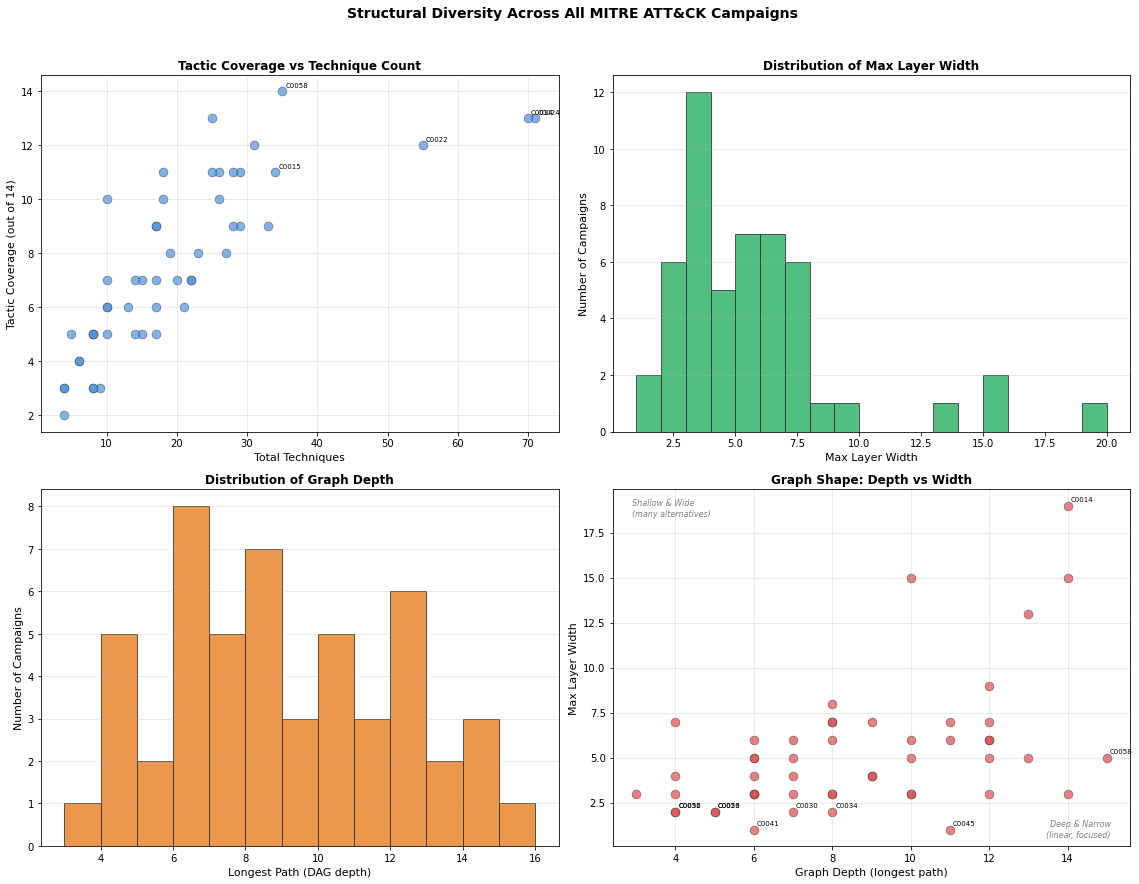


Most LINEAR campaign: C0045 ShadowRay (max width=1, 10 techniques)
Most BUSHY campaign:  C0014 Operation Wocao (max width=19, 70 techniques)


In [12]:
# Structural diversity visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tactic coverage vs total techniques (scatter)
ax = axes[0, 0]
techs = [m['num_techniques'] for m in all_campaign_metrics]
coverages = [m['tactic_coverage'] for m in all_campaign_metrics]
ax.scatter(techs, coverages, s=80, alpha=0.7, color='#4A90D9', edgecolors='#333', linewidths=0.5)

# Label outliers (top 5 by technique count)
for m in all_campaign_metrics[:5]:
    ax.annotate(m['campaign_id'], (m['num_techniques'], m['tactic_coverage']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Total Techniques', fontsize=11)
ax.set_ylabel('Tactic Coverage (out of 14)', fontsize=11)
ax.set_title('Tactic Coverage vs Technique Count', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# 2. Max width histogram
ax = axes[0, 1]
max_widths = [m['max_width'] for m in all_campaign_metrics]
ax.hist(max_widths, bins=range(1, max(max_widths) + 2), color='#27AE60', alpha=0.8, edgecolor='#333')
ax.set_xlabel('Max Layer Width', fontsize=11)
ax.set_ylabel('Number of Campaigns', fontsize=11)
ax.set_title('Distribution of Max Layer Width', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 3. Longest path distribution
ax = axes[1, 0]
paths = [m['longest_path'] for m in all_campaign_metrics]
ax.hist(paths, bins=range(min(paths), max(paths) + 2), color='#E67E22', alpha=0.8, edgecolor='#333')
ax.set_xlabel('Longest Path (DAG depth)', fontsize=11)
ax.set_ylabel('Number of Campaigns', fontsize=11)
ax.set_title('Distribution of Graph Depth', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. Max width vs longest path (shape characterization)
ax = axes[1, 1]
ax.scatter(paths, max_widths, s=80, alpha=0.7, color='#D94A4A', edgecolors='#333', linewidths=0.5)

# Label extremes
for m in all_campaign_metrics:
    if m['max_width'] == max(max_widths) or m['longest_path'] == max(paths) or m['max_width'] <= 2:
        ax.annotate(m['campaign_id'], (m['longest_path'], m['max_width']),
                    fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Graph Depth (longest path)', fontsize=11)
ax.set_ylabel('Max Layer Width', fontsize=11)
ax.set_title('Graph Shape: Depth vs Width', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Quadrant labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
mid_x = (xlim[0] + xlim[1]) / 2
mid_y = (ylim[0] + ylim[1]) / 2
ax.text(xlim[0] + 0.5, ylim[1] - 0.5, 'Shallow & Wide\n(many alternatives)', 
        fontsize=8, color='gray', va='top', style='italic')
ax.text(xlim[1] - 0.5, ylim[0] + 0.5, 'Deep & Narrow\n(linear, focused)', 
        fontsize=8, color='gray', ha='right', style='italic')

plt.suptitle('Structural Diversity Across All MITRE ATT&CK Campaigns', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Identify extremes
most_linear = min(all_campaign_metrics, key=lambda m: m['max_width'])
most_bushy = max(all_campaign_metrics, key=lambda m: m['max_width'])
print(f"\nMost LINEAR campaign: {most_linear['campaign_id']} {most_linear['campaign_name']} "
      f"(max width={most_linear['max_width']}, {most_linear['num_techniques']} techniques)")
print(f"Most BUSHY campaign:  {most_bushy['campaign_id']} {most_bushy['campaign_name']} "
      f"(max width={most_bushy['max_width']}, {most_bushy['num_techniques']} techniques)")

## Part 5: How Attack Graphs Could Drive Simulator Behaviour

### Current Model Limitations
The fixed 6-phase kill chain treats every campaign identically in terms of **structure**. A SolarWinds APT with 71 techniques across 13 tactics follows the exact same SCAN_HOST → ENUM_HOST → SCAN_PORT → EXPLOIT_VULN → BRUTE_FORCE → SCAN_NEIGHBOR chain as a simple 5-technique campaign. Only durations and probabilities change.

### Graph-Driven Attack Behaviour

**1. Graph-driven phase selection**: Instead of the fixed chain, the attacker walks its campaign-specific attack graph. At each layer, it selects from available technique nodes. This means different campaigns literally follow different paths through the simulation.

**2. Width as attacker resilience**: Wider layers = more alternative paths. If an MTD disrupts one technique path, a campaign with 8 initial-access techniques has 7 fallbacks. A campaign with only 1 initial-access technique is stuck. This creates a natural "resilience" property that emerges from graph structure.

**3. MTD effectiveness varies by graph shape**: 
- **Network shuffle** is devastating against lateral-movement-heavy campaigns (wide SCAN_NEIGHBOR layers) but barely affects credential-focused ones
- **Service diversity** matters most for campaigns with wide EXPLOIT_VULN layers
- The attack graph structure predicts which MTD strategies are effective against which threat actors

**4. Technique-specific actions**: Instead of generic "exploit vuln", specific techniques (T1190 Exploit Public-Facing Application vs T1195 Supply Chain Compromise) could map to different host-targeting strategies, success probabilities, and time costs.

**5. Choke-point analysis**: Narrow layers in a campaign's attack graph are natural choke points — if an MTD can disrupt the single technique at a bottleneck layer, the entire campaign stalls. This enables strategic MTD deployment.

### Limitations of This Approach

- **Bipartite layer connections are an over-approximation**: Not every technique in layer N truly enables every technique in layer N+1. Refining edges requires domain knowledge or NLP on relationship descriptions.
- **Tactic ordering is coarse**: Some campaigns may use techniques out of the canonical order (e.g., credential access before initial access via phishing).
- **Within-layer parallelism is assumed**: We assume all techniques in a layer are alternatives, but some may be sequential steps within the same tactic.

## Summary & Next Steps

### What we established today
1. **MITRE ATT&CK has no pre-built attack graphs** — the data is flat campaign-to-technique relationships
2. **The canonical tactic ordering provides a natural DAG layering** — 14 tactics in matrix order
3. **Campaign attack graphs are structurally diverse** — different tactic coverage, width profiles, depths
4. **This structural diversity is lost in the current model** — all profiles use the same 6-phase chain

### Next steps
1. **Define a `CampaignAttackGraph` class** wrapping `nx.DiGraph` with the construction logic developed here
2. **Edge refinement**: Use relationship descriptions and domain knowledge to prune bipartite edges to more realistic technique dependencies
3. **Technique-to-action mapping**: Map ATT&CK techniques to simulator actions (many-to-one, but graph structure determines ordering and alternatives)
4. **Modify `AttackOperation.proceed_attack()`** to walk the campaign graph instead of the fixed chain
5. **Evaluate**: Run simulations with graph-driven attackers vs current linear attackers to quantify the difference in MTD effectiveness